# Imaginary time evolution of the transverse field Ising model
We find the ground state of the transverse field Ising model by evolving a matrix product state (MPS) in imaginary time,
$$
|\psi(\tau)\rangle = \frac{e^{-\tau H}|\psi(0)\rangle}{\|e^{-\tau H}|\psi(0)\rangle\|} \xrightarrow{\tau\to\infty} |\psi_0\rangle .
$$
The code is written for a general time step $t$ of $e^{-itH}$; imaginary time evolution with step $\tau$ uses $t = -i\tau$.

## Install
Import Cytnx, see https://cytnx-dev.github.io/Cytnx/
and
https://github.com/Cytnx-dev/Cytnx/issues/1189

```console
$python -m pip install -U --pre --extra-index-url https://pypi.anaconda.org/cytnx-nightly-wheels/simple
cytnx-cuda
```
or
```console
pixi add --pypi cytnx-cuda --index https://pypi.anaconda.org/cytnx-nightly-wheels/simple
```

In [ ]:
# The following 2 lines are only needed if you installed Cytnx from source
# import sys
# sys.path.insert(0,'/home/manuel/Cytnx_lib') # change to your installation path

# The tensors in this notebook are small, so multithreading only adds overhead.
# The number of threads must be set before cytnx is imported.
import os
os.environ["OMP_NUM_THREADS"] = "1"

import cytnx
import cmath
import math
import time
import matplotlib.pyplot as plt
print(cytnx.__version__)

1.1.1


## Hamiltonian
The same Hamiltonian as in `Ising.ipynb`:
$$
H = J \sum_{k=0}^{N-2} \sigma_k^x \sigma_{k+1}^x + \beta \sum_{k=0}^{N-1} \sigma_k^z
$$
$D$ is the maximal bond dimension of the MPS.

In [2]:
J = 1
beta = -0.7
D = 16

## MPS and MPO tensors
We use the conventions of `Ising.ipynb`, with site-dependent labels such that `Contract` connects the right indices:
* MPS tensor $A_k$ of site $k$: indices `b{k}` (incoming), `s_{k}` (incoming), `b{k+1}` (outgoing). The bond `b{k}` connects site $k-1$ with site $k$. The first and the last tensor have a bond of dimension 1 at the boundary, so that all sites are treated in the same way.
* MPO tensor $W_k$ of site $k$: indices `v{k}`, `v{k+1}` (virtual), `s'_{k}` (connects to the bra) and `s_{k}` (connects to the ket). Again, the boundary bonds have dimension 1.

The following functions wrap a `cytnx.Tensor` into a `UniTensor` with these labels and bond directions.

In [3]:
def mps_tensor(data, k):
    # MPS tensor of site k from a Tensor of shape (D_left, 2, D_right)
    Dl, d, Dr = data.shape()
    A = cytnx.UniTensor([cytnx.Bond(Dl, cytnx.BD_KET), cytnx.Bond(d, cytnx.BD_KET), cytnx.Bond(Dr, cytnx.BD_BRA)],
                        labels=[f"b{k}", f"s_{k}", f"b{k+1}"], rowrank=2, dtype=data.dtype(), name=f"A{k}")
    A.put_block(data.contiguous())
    return A

def mpo_tensor(data, k):
    # MPO tensor of site k from a Tensor of shape (D_left, D_right, 2, 2) with indices (v_k, v_k+1, s'_k, s_k)
    Dl, Dr, d, _ = data.shape()
    W = cytnx.UniTensor([cytnx.Bond(Dl, cytnx.BD_KET), cytnx.Bond(Dr, cytnx.BD_BRA),
                         cytnx.Bond(d, cytnx.BD_KET), cytnx.Bond(d, cytnx.BD_BRA)],
                        labels=[f"v{k}", f"v{k+1}", f"s'_{k}", f"s_{k}"], rowrank=2, dtype=data.dtype(), name=f"W{k}")
    W.put_block(data.contiguous())
    return W

The Hamiltonian MPO is built from the same $B$ tensor as in `Ising.ipynb`. Instead of contracting boundary vectors, we keep only the first row of $B$ on the first site and the last column of $B$ on the last site; this leaves boundary bonds of dimension 1.

In [4]:
def ising_mpo(N, J, beta):
    sx = cytnx.physics.pauli("x").real()
    sz = cytnx.physics.pauli("z").real()
    I = cytnx.eye(2)
    B_data = cytnx.zeros([3, 3, 2, 2])
    B_data[0, 0, :, :] = I
    B_data[0, 1, :, :] = J * sx
    B_data[0, 2, :, :] = beta * sz
    B_data[1, 2, :, :] = sx
    B_data[2, 2, :, :] = I
    mpo = []
    for k in range(N):
        data = B_data
        if k == 0:
            data = data[0:1, :, :, :]  # first row
        if k == N - 1:
            data = data[:, 2:3, :, :]  # last column
        mpo.append(mpo_tensor(data.clone(), k))
    return mpo

As initial state, we use the product state with all spins up, $|\uparrow\uparrow\cdots\uparrow\rangle$. It has bond dimension 1; the time evolution increases the bond dimension up to $\chi$.

*Why not a random state?* For $|\beta| < |J|$, the two lowest eigenstates are almost degenerate: they are the symmetric and antisymmetric combinations of the two ordered states, with an energy gap that vanishes exponentially with $N$. Imaginary time evolution would need an extremely long time to separate them. Both states have a different parity $P = \prod_k \sigma^z_k$, and $H$ conserves the parity. The all-up state has $P=+1$ like the ground state, so the evolution never reaches the antisymmetric state.

In [5]:
def product_state(N):
    data = cytnx.zeros([1, 2, 1])
    data[0, 0, 0] = 1  # spin up
    return [mps_tensor(data.clone(), k) for k in range(N)]

## Trotter decomposition
We split $H = H_e + H_o$ into two blocks of commuting two-site terms:
$$
H_e = \sum_{k \text{ even}} h_{k,k+1}, \qquad H_o = \sum_{k \text{ odd}} h_{k,k+1}, \qquad
h_{k,k+1} = J \sigma^x_k \sigma^x_{k+1} + \beta_k \sigma^z_k + \beta_{k+1} \sigma^z_{k+1}
$$
Every bulk site belongs to two bonds, so the field term enters each bond with $\beta_k = \beta/2$. The boundary sites $0$ and $N-1$ belong to only one bond and keep the full $\beta_0 = \beta_{N-1} = \beta$.

The terms within $H_e$ (or $H_o$) act on different sites and commute, so $e^{-itH_e}$ is exactly the product of the two-site gates $e^{-ith_{k,k+1}}$. The Trotter decompositions of first and second order are
$$
e^{-itH} = e^{-itH_o} e^{-itH_e} + \mathcal{O}(t^2), \qquad
e^{-itH} = e^{-i\frac{t}{2}H_e} e^{-itH_o} e^{-i\frac{t}{2}H_e} + \mathcal{O}(t^3) .
$$

We build $h_{k,k+1}$ as a `UniTensor` from single-site operators with the indices `s'_{k}` and `s_{k}`. `Contract` of two tensors without common labels is their tensor product, so $\sigma^x_k \sigma^x_{k+1}$ is `Contract(sx_k, sx_k+1)`. Sums of UniTensors are taken label by label.

In [6]:
def site_op(op, k):
    # single-site operator with indices s'_k (incoming) and s_k (outgoing)
    O = cytnx.UniTensor([cytnx.Bond(2, cytnx.BD_KET), cytnx.Bond(2, cytnx.BD_BRA)],
                        labels=[f"s'_{k}", f"s_{k}"], rowrank=1, dtype=op.dtype())
    O.put_block(op.clone())
    return O

def unit_bond(label, bondtype):
    # trivial bond of dimension 1
    T = cytnx.UniTensor([cytnx.Bond(1, bondtype)], labels=[label], rowrank=0)
    T.at([0]).value = 1
    return T

def bond_hamiltonian(J, beta, k, N):
    # h_{k,k+1} with indices s'_k, s_k, s'_k+1, s_k+1
    sx = cytnx.physics.pauli("x").real()
    sz = cytnx.physics.pauli("z").real()
    I = cytnx.eye(2)
    beta_l = beta if k == 0 else beta / 2
    beta_r = beta if k + 1 == N - 1 else beta / 2
    return (J * cytnx.Contract(site_op(sx, k), site_op(sx, k + 1))
            + beta_l * cytnx.Contract(site_op(sz, k), site_op(I, k + 1))
            + beta_r * cytnx.Contract(site_op(I, k), site_op(sz, k + 1)))

Each gate $g = e^{-ith_{k,k+1}}$ becomes two MPO tensors. `ExpH(h, a)` computes $e^{a h}$ of the matrix with the row indices $(s'_k, s'_{k+1})$ and the column indices $(s_k, s_{k+1})$, so we first permute $h$ by labels and set `rowrank=2`. For imaginary time, $a = -it = -\tau$ is real, and we pass it as a real number to keep real tensors.

Then we permute the gate to the row indices $(s'_k, s_k)$ and the column indices $(s'_{k+1}, s_{k+1})$ and split it by an SVD, $g = U S V^\dagger$. $U$ is the MPO tensor of site $k$, $S V^\dagger$ the one of site $k+1$, and the new index between them becomes `v{k+1}`. The boundary bonds `v{k}` and `v{k+2}` of dimension 1 are added as a tensor product with `unit_bond`. The gate MPO has bond dimension at most 4 on the bonds inside a gate and 1 between gates. Sites that are not covered by a gate (the first site in $H_o$, the last site for some $N$) get the identity.

In [7]:
def gate_mpo(N, J, beta, t, parity):
    # MPO of exp(-i t H_e) (parity=0) or exp(-i t H_o) (parity=1)
    a = -1j * t
    if a.imag == 0:
        a = a.real
    mpo = []
    k = 0
    while k < N:
        if k % 2 == parity and k + 1 < N:
            h = bond_hamiltonian(J, beta, k, N)
            g = cytnx.linalg.ExpH(h.permute([f"s'_{k}", f"s'_{k+1}", f"s_{k}", f"s_{k+1}"], rowrank=2), a)
            S, U, V = cytnx.linalg.Svd(g.permute([f"s'_{k}", f"s_{k}", f"s'_{k+1}", f"s_{k+1}"], rowrank=2))
            left = cytnx.Contract(unit_bond(f"v{k}", cytnx.BD_KET), U).relabel("_aux_L", f"v{k+1}")
            right = cytnx.Contract(cytnx.Contract(S, V), unit_bond(f"v{k+2}", cytnx.BD_BRA)).relabel("_aux_L", f"v{k+1}")
            mpo += [left, right]
            k += 2
        else:
            identity = cytnx.Contract(unit_bond(f"v{k}", cytnx.BD_KET), site_op(cytnx.eye(2), k))
            mpo.append(cytnx.Contract(identity, unit_bond(f"v{k+1}", cytnx.BD_BRA)))
            k += 1
    return mpo

## Gauge
`gauge(psi, site)` brings the MPS into the central form around `site`: all tensors left of `site` are left-orthonormal, all tensors right of it are right-orthonormal,
$$
\sum_{b_k, s_k} A^{s_k}_{b_k b_{k+1}} \bar{A}^{s_k}_{b_k b'_{k+1}} = \delta_{b_{k+1} b'_{k+1}}
\quad \text{(left-orthonormal)}, \qquad
\sum_{s_k, b_{k+1}} A^{s_k}_{b_k b_{k+1}} \bar{A}^{s_k}_{b'_k b_{k+1}} = \delta_{b_k b'_k}
\quad \text{(right-orthonormal)} .
$$
We go from the left to `site` with SVDs $A_k = U S V^\dagger$, keep $U$ and move $S V^\dagger$ into the next tensor; then we go from the right to `site` and move $U S$ into the previous tensor. The function returns the singular values of the last SVD.

For `site=-1` (all tensors right-orthonormal) or `site=N` (all left-orthonormal), the last SVD acts on the boundary bond of dimension 1. Its single singular value is the norm $\|\psi\|$, and the returned state is normalized.

In [8]:
def gauge(psi, site):
    N = len(psi)
    psi = [A.clone() for A in psi]
    S = None
    for k in range(min(site, N)):  # left-orthonormalize the sites left of site
        A = psi[k].permute([f"b{k}", f"s_{k}", f"b{k+1}"], rowrank=2)
        S, U, V = cytnx.linalg.Svd(A)
        psi[k] = U.relabel("_aux_L", f"b{k+1}")
        if k + 1 < N:
            psi[k + 1] = cytnx.Contract(cytnx.Contract(S, V), psi[k + 1]).relabel("_aux_L", f"b{k+1}")
        else:
            psi[k] = cytnx.Contract(U, V.relabel("_aux_R", "_aux_L"))  # 1x1 V is a phase, S is the norm
    for k in range(N - 1, max(site, -1), -1):  # right-orthonormalize the sites right of site
        A = psi[k].permute([f"b{k}", f"s_{k}", f"b{k+1}"], rowrank=1)
        S, U, V = cytnx.linalg.Svd(A)
        psi[k] = V.relabel("_aux_R", f"b{k}")
        if k > 0:
            psi[k - 1] = cytnx.Contract(psi[k - 1], cytnx.Contract(U, S)).relabel("_aux_R", f"b{k}")
        else:
            psi[k] = cytnx.Contract(U.relabel("_aux_L", "_aux_R"), V)  # 1x1 U is a phase, S is the norm
    for k in range(N):
        psi[k] = psi[k].permute([f"b{k}", f"s_{k}", f"b{k+1}"], rowrank=2)
    svals = [] if S is None else [S.get_block()[j].item() for j in range(S.shape()[0])]
    return psi, svals

## Environments and expectation values
We contract networks of the form $\langle \text{bra}|O|\text{ket}\rangle$ site by site. The **left environment** $L_k$ contains all sites $< k$, the **right environment** $R_k$ all sites $\geq k$. Both are stored in one list `env` of length $N+1$: during a sweep with the current site $k$, the entries `env[j]` with $j \leq k$ are left environments and the entries with $j > k$ are right environments. Moving the current site overwrites the environment that is no longer needed:
* `move_left(env, k, ...)`: $L_{k+1} = L_k \cdot \text{ket}_k \cdot O_k \cdot \overline{\text{bra}}_k$, stored in `env[k+1]`,
* `move_right(env, k, ...)`: $R_k = \text{ket}_k \cdot O_k \cdot \overline{\text{bra}}_k \cdot R_{k+1}$, stored in `env[k]`,
* `close_env(env, k, ...)`: $L_k \cdot \text{ket}_k \cdot O_k \cdot \overline{\text{bra}}_k \cdot R_{k+1}$, the full network.

`env[0]` and `env[N]` are the trivial environments at the boundaries (all bonds have dimension 1). Without an operator (`op=None`), the network is the overlap $\langle\text{bra}|\text{ket}\rangle$.

The bra tensors are obtained from the ket tensors one by one: `Dagger` conjugates the tensor and flips its bond directions. The virtual indices of the bra are relabeled `b{k}` $\to$ `c{k}`, and its physical index `s_{k}` $\to$ `s'_{k}` if it connects to the operator.

In [9]:
def bra_tensor(bra, k, with_op):
    old = [f"b{k}", f"b{k+1}"]
    new = [f"c{k}", f"c{k+1}"]
    if with_op:
        old.append(f"s_{k}")
        new.append(f"s'_{k}")
    return bra[k].Dagger().relabel(old, new)

def init_env(ket, op, bra):
    N = len(ket)
    env = [None] * (N + 1)
    for j, k in [(0, 0), (N, N - 1)]:  # boundary bond j at site k
        bonds = [ket[k].bond(f"b{j}").redirect()]
        labels = [f"b{j}"]
        if op is not None:
            bonds.append(op[k].bond(f"v{j}").redirect())
            labels.append(f"v{j}")
        bonds.append(bra[k].bond(f"b{j}"))  # Dagger flips the direction of the bra bond
        labels.append(f"c{j}")
        E = cytnx.UniTensor(bonds, labels=labels, rowrank=len(bonds))
        E.at([0] * len(bonds)).value = 1
        env[j] = E
    return env

def absorb(E, k, ket, op, bra):
    # contract the environment E with the tensors of site k
    E = cytnx.Contract(E, ket[k])
    if op is not None:
        E = cytnx.Contract(E, op[k])
    return cytnx.Contract(E, bra_tensor(bra, k, op is not None))

def move_left(env, k, ket, op, bra):
    env[k + 1] = absorb(env[k], k, ket, op, bra)

def move_right(env, k, ket, op, bra):
    env[k] = absorb(env[k + 1], k, ket, op, bra)

def close_env(env, k, ket, op, bra):
    return cytnx.Contract(absorb(env[k], k, ket, op, bra), env[k + 1]).item()

`exp_val(ket, op, bra)` computes $\langle\text{bra}|O|\text{ket}\rangle$ by moving the left environment from the left to the right boundary. If no bra is given, the bra is the ket itself; if no operator is given, it computes the overlap. The energy is $E = \langle\psi|H|\psi\rangle / \langle\psi|\psi\rangle$, and for normalized states the fidelity is $F = |\langle\phi|\psi\rangle|$ = `abs(exp_val(psi, bra=phi))`.

In [10]:
def exp_val(ket, op=None, bra=None):
    if bra is None:
        bra = ket
    N = len(ket)
    env = init_env(ket, op, bra)
    for k in range(N - 1):
        move_left(env, k, ket, op, bra)
    return close_env(env, N - 1, ket, op, bra)

def energy(psi, H):
    return (exp_val(psi, H) / exp_val(psi)).real

## Applying an MPO to an MPS
We look for the MPS $|\psi_\text{new}\rangle$ with bond dimension $\chi$ that is closest to $O|\psi\rangle$, by maximizing $|\langle\psi_\text{new}|O|\psi\rangle| / \|\psi_\text{new}\|$. We optimize two neighboring tensors at a time:
1. Initial guess: $\psi_\text{new} = \psi$, right-orthonormalized with `gauge(psi, -1)`. Compute the right environments of $\langle\psi_\text{new}|O|\psi\rangle$.
2. **Right sweep**, for $k = 0, \dots, N-2$: contract $L_k$, $\psi_k$, $\psi_{k+1}$, $O_k$, $O_{k+1}$ and $R_{k+2}$. Since all other tensors of $\psi_\text{new}$ are orthonormal, this is the optimal two-site tensor $\Theta$ of $\psi_\text{new}$. A truncated SVD $\Theta \approx U S V^\dagger$ keeps the $\chi$ largest singular values; $\psi_{\text{new},k} = U$ (left-orthonormal) and $\psi_{\text{new},k+1} = S V^\dagger$. Then we move the left environment one site further.
3. **Left sweep**, for $k = N-2, \dots, 0$: the same, but $\psi_{\text{new},k+1} = V^\dagger$ (right-orthonormal) and $\psi_{\text{new},k} = U S$. Then we move the right environment one site further.

After a right sweep, all tensors except the last one, $\psi_{\text{new},N-1}$, are left-orthonormal; after a left sweep, all tensors except the first one, $\psi_{\text{new},0}$, are right-orthonormal. The norm $\|\psi_\text{new}\|$ is the norm of this center tensor. The overlap $\langle\psi_\text{new}|O|\psi\rangle$ is obtained by closing the network at the center: with $L_{N-1}$ and $R_N$ after a right sweep, with $L_0$ and $R_1$ after a left sweep. The quantity $f = |\langle\psi_\text{new}|O|\psi\rangle| / \|\psi_\text{new}\| = F \, \|O\psi\|$ is the fidelity $F$ of $\psi_\text{new}$ with $O\psi$ up to the constant factor $\|O\psi\|$.

Convergence criteria for the sweeps, checked after every right and every left sweep:
* at most `maxit` iterations (one right and one left sweep form one iteration),
* stop if the relative change of $f$ between two sweeps is at most `tol` (`tol=0` switches this off).

The gates of the Trotter decomposition act on disjoint pairs of sites, and the two-site update optimizes every pair at once. Therefore, the first right sweep usually reaches the optimum already, and the second sweep only confirms the convergence.

If `normalize=True`, the center tensor is divided by the norm. The function returns $\psi_\text{new}$, its norm before normalization and the list of $f$ values.

In [11]:
def two_site_tensor(env, k, psi, op):
    T = cytnx.Contract(env[k], psi[k])
    T = cytnx.Contract(T, op[k])
    T = cytnx.Contract(T, psi[k + 1])
    T = cytnx.Contract(T, op[k + 1])
    T = cytnx.Contract(T, env[k + 2])
    # the open indices of T are the ket indices of psi_new
    T.relabel_([f"c{k}", f"s'_{k}", f"s'_{k+1}", f"c{k+2}"], [f"b{k}", f"s_{k}", f"s_{k+1}", f"b{k+2}"])
    return T.permute([f"b{k}", f"s_{k}", f"s_{k+1}", f"b{k+2}"], rowrank=2)

def apply_mpo(psi, op, chi=None, maxit=20, tol=0, normalize=False):
    N = len(psi)
    if chi is None:  # bond dimension of psi
        chi = max(A.bond(f"b{k+1}").dim() for k, A in enumerate(psi))
    new, _ = gauge(psi, -1)
    env = init_env(psi, op, new)
    for k in range(N - 1, 1, -1):
        move_right(env, k, psi, op, new)
    fids = []
    for sweep in range(2 * maxit):
        if sweep % 2 == 0:  # right sweep
            for k in range(N - 1):
                S, U, V = cytnx.linalg.Svd_truncate(two_site_tensor(env, k, psi, op), keepdim=chi, err=1e-14)
                new[k] = U.relabel("_aux_L", f"b{k+1}")
                new[k + 1] = cytnx.Contract(S, V).relabel("_aux_L", f"b{k+1}")
                move_left(env, k, psi, op, new)
            center = N - 1
        else:  # left sweep
            for k in range(N - 2, -1, -1):
                S, U, V = cytnx.linalg.Svd_truncate(two_site_tensor(env, k, psi, op), keepdim=chi, err=1e-14)
                new[k + 1] = V.relabel("_aux_R", f"b{k+1}")
                new[k] = cytnx.Contract(U, S).relabel("_aux_R", f"b{k+1}")
                move_right(env, k + 1, psi, op, new)
            center = 0
        norm = new[center].norm()
        fids.append(abs(close_env(env, center, psi, op, new)) / norm)
        if sweep > 0 and abs(fids[-1] - fids[-2]) <= tol * fids[-1]:
            break
    if normalize:
        new[center] = new[center] / norm
    return new, norm, fids

## Time evolution
`time_evolve` applies the Trotter steps
* `order=1`: $e^{-itH_e}$, then $e^{-itH_o}$,
* `order=2`: $e^{-i\frac{t}{2}H_e}$, $e^{-itH_o}$, $e^{-i\frac{t}{2}H_e}$ (the half steps of consecutive time steps are not merged, so that we can measure the energy after every step).

If $t$ is not real, the state is normalized after each gate. The product of the norms of one time step is stored in `norms`; for imaginary time and a converged state it approaches $e^{-\tau E_0}$.

Convergence criteria for the time steps:
* at most `nsteps` steps,
* stop if the relative change of the energy in one step is at most `steptol` (`steptol=0` switches this off).

`chi` is the maximal bond dimension (default: the bond dimension of the initial state), `maxit` and `tol` are passed to `apply_mpo`. With `save_states=True`, the states after every step are returned as well. `runtimes` contains the accumulated wall-clock time of the gate applications after every step; the energy measurements are not included.

In [12]:
def time_evolve(psi, J, beta, t, chi=None, order=1, nsteps=100, steptol=0, maxit=20, tol=0, save_states=False):
    N = len(psi)
    H = ising_mpo(N, J, beta)
    if order == 1:
        gates = [gate_mpo(N, J, beta, t, 0), gate_mpo(N, J, beta, t, 1)]
    elif order == 2:
        half = gate_mpo(N, J, beta, t / 2, 0)
        gates = [half, gate_mpo(N, J, beta, t, 1), half]
    else:
        raise ValueError("order must be 1 or 2")
    normalize = complex(t).imag != 0
    if normalize:
        psi, _ = gauge(psi, -1)
    energies = [energy(psi, H)]
    norms = []
    all_psi = [psi] if save_states else None
    runtimes = [0]
    for step in range(nsteps):
        start = time.perf_counter()
        norm = 1
        for G in gates:
            psi, n, _ = apply_mpo(psi, G, chi, maxit, tol, normalize)
            norm *= n
        runtimes.append(runtimes[-1] + time.perf_counter() - start)
        energies.append(energy(psi, H))
        norms.append(norm)
        if save_states:
            all_psi.append(psi)
        if steptol > 0 and abs(energies[-1] - energies[-2]) <= steptol * abs(energies[-1]):
            break
    return energies, psi, norms, all_psi, runtimes

### Decreasing the time step
A large time step $\tau$ converges quickly in imaginary time, but to a state with a large Trotter error. A small time step has a small Trotter error, but needs many steps. `evolve` combines both: it evolves with the time steps `taus[0]`, `taus[1]`, ... one after another. It goes on to the next time step when the relative energy change per step is at most `switchtol`; with the last time step, it stops at `steptol`. With `taus = [tau]`, it is a plain imaginary time evolution.

The function collects the results in a dictionary: the energies and states after every step, the imaginary time $\sum \tau$, the accumulated runtime, the time step and the norm of every step. The other keyword arguments are passed to `time_evolve`.

In [13]:
def evolve(psi, J, beta, taus, order, label, switchtol=0, steptol=0, **kwargs):
    run = dict(label=label, order=order, energies=[], states=[], imag_time=[], runtime=[], taus=[], norms=[])
    for j, tau in enumerate(taus):
        last = j == len(taus) - 1
        energies, psi, norms, states, runtimes = time_evolve(psi, J, beta, -1j * tau, order=order, save_states=True,
                                                             steptol=steptol if last else switchtol, **kwargs)
        skip = 0 if j == 0 else 1  # the first entry repeats the last state of the previous time step
        t0 = run["imag_time"][-1] if j > 0 else 0
        r0 = run["runtime"][-1] if j > 0 else 0
        run["energies"] += energies[skip:]
        run["states"] += states[skip:]
        run["imag_time"] += [t0 + n * tau for n in range(skip, len(energies))]
        run["runtime"] += [r0 + r for r in runtimes[skip:]]
        run["taus"] += [tau] * (len(energies) - skip)
        run["norms"] += norms
    return run

## Reference results
For small systems, we compute the exact ground state as in `Ising.ipynb`: contract the Hamiltonian MPO into a $2^N \times 2^N$ matrix and diagonalize it with `Eigh`. The ground state vector is split into an MPS by successive SVDs, without truncation.

In [14]:
def dense_hamiltonian(N, J, beta):
    mpo = ising_mpo(N, J, beta)
    H = mpo[0]
    for k in range(1, N):
        H = cytnx.Contract(H, mpo[k])
    row_labels = ["v0"] + [f"s'_{k}" for k in range(N)]
    col_labels = [f"v{N}"] + [f"s_{k}" for k in range(N)]
    H = H.permute(row_labels + col_labels, rowrank=N + 1)
    return H.get_block().contiguous().reshape(2 ** N, 2 ** N)

def dense_to_mps(psi, N):
    tensors = []
    rest = psi.clone().reshape(1, -1)
    for k in range(N - 1):
        Dl = rest.shape()[0]
        M = rest.reshape(Dl * 2, -1)
        S, U, Vt = cytnx.linalg.Svd_truncate(M, keepdim=M.shape()[0], err=1e-14)
        r = S.shape()[0]
        tensors.append(mps_tensor(U.reshape(Dl, 2, r), k))
        rest = cytnx.linalg.Matmul(cytnx.linalg.Diag(S), Vt)
    tensors.append(mps_tensor(rest.reshape(rest.shape()[0], 2, 1), N - 1))
    return tensors

def exact_ground_state(N, J, beta):
    eigvals, V = cytnx.linalg.Eigh(dense_hamiltonian(N, J, beta))
    return eigvals[0].item(), dense_to_mps(V[:, 0].contiguous(), N)

`plot_convergence` shows the relative energy error $|E - E_\text{ref}| / |E_\text{ref}|$ and the infidelity $1 - F$ with the reference state, as a function of the imaginary time (left) and of the runtime (right). Each run is a dictionary returned by `evolve`.

In [15]:
def plot_convergence(runs, E_ref, psi_ref, title):
    colors = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]  # one color per run
    fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey="row")
    for color, run in zip(colors, runs):
        energy_error = [max(abs(E - E_ref) / abs(E_ref), 1e-16) for E in run["energies"]]
        infidelity = [max(1 - abs(exp_val(psi, bra=psi_ref)), 1e-16) for psi in run["states"]]
        for col, x in enumerate([run["imag_time"], run["runtime"]]):
            axes[0, col].semilogy(x, energy_error, "o", color=color, markersize=3, label=run["label"])
            axes[1, col].semilogy(x, infidelity, "o", color=color, markersize=3, label=run["label"])
    axes[0, 0].set_ylabel(r"relative energy error $|E - E_\mathrm{ref}| / |E_\mathrm{ref}|$")
    axes[1, 0].set_ylabel(r"infidelity $1 - F$")
    for row in range(2):
        axes[row, 0].set_xlabel(r"imaginary time $\sum \tau$")
        axes[row, 1].set_xlabel("runtime [s]")
    for ax in axes.flat:
        ax.grid(True, which="both", alpha=0.3)
    axes[0, 1].legend(fontsize="small")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

## Small system: comparison with the exact ground state
We evolve the all-up state with $\chi = D = 16 = 2^{N/2}$, so there is no truncation and only the Trotter error remains. The time steps are $\tau = 0.1$ and $\tau = 0.05$, each with the first and the second order Trotter decomposition. The last run uses the second order and halves the time step from $\tau = 0.4$ down to $\tau = 0.025$, each time when the relative energy change per step is below $10^{-8}$.

The sweeps in `apply_mpo` stop when $f$ changes by less than $10^{-10}$, the time evolution when the energy changes by less than $10^{-11}$.

In [16]:
N = 8
E0, psi0 = exact_ground_state(N, J, beta)
print("exact ground state energy: E0 =", E0)

settings = dict(chi=D, nsteps=5000, steptol=1e-11, maxit=20, tol=1e-10)
small_runs = [evolve(product_state(N), J, beta, [tau], order, f"order {order}, $\\tau$ = {tau}", **settings)
              for tau in [0.1, 0.05] for order in [1, 2]]
small_runs.append(evolve(product_state(N), J, beta, [0.4, 0.2, 0.1, 0.05, 0.025], 2,
                         "order 2, $\\tau$ = 0.4 $\\to$ 0.025", switchtol=1e-8, **settings))

for run in small_runs:
    print("%-30s %4d steps, runtime %5.1f s, relative energy error = %.2e, infidelity = %.2e, -ln(norm)/tau = %.8f"
          % (run["label"], len(run["energies"]) - 1, run["runtime"][-1], abs(run["energies"][-1] - E0) / abs(E0),
             1 - abs(exp_val(run["states"][-1], bra=psi0)), -math.log(run["norms"][-1]) / run["taus"][-1]))

exact ground state energy: E0 = -8.305610965881472


order 1, $\tau$ = 0.1           140 steps, runtime   0.9 s, relative energy error = 2.52e-04, infidelity = 2.89e-04, -ln(norm)/tau = -8.30631352
order 2, $\tau$ = 0.1           140 steps, runtime   1.2 s, relative energy error = 6.98e-07, infidelity = 1.11e-06, -ln(norm)/tau = -8.30631352
order 1, $\tau$ = 0.05          258 steps, runtime   1.9 s, relative energy error = 6.32e-05, infidelity = 7.30e-05, -ln(norm)/tau = -8.30578680
order 2, $\tau$ = 0.05          240 steps, runtime   2.0 s, relative energy error = 4.39e-08, infidelity = 7.03e-08, -ln(norm)/tau = -8.30578679
order 2, $\tau$ = 0.4 $\to$ 0.025  229 steps, runtime   2.0 s, relative energy error = 3.06e-09, infidelity = 5.61e-09, -ln(norm)/tau = -8.30565493


The energy and fidelity converge exponentially in the imaginary time, with a rate given by the energy gap to the first excited state with the same parity. The final error is the Trotter error. The converged state deviates from the ground state by $\mathcal{O}(\tau)$ for the first order and $\mathcal{O}(\tau^2)$ for the second order. Both the energy error and the infidelity are quadratic in this deviation, so halving $\tau$ reduces them by a factor of about 4 for the first order and about 16 for the second order.

The run with the decreasing time step first converges quickly with the large time steps and then removes the Trotter error with the small ones. It reaches a lower energy than the runs with a fixed time step, in a comparable runtime.

The last column shows that the norm of one time step applied to the converged state is $e^{-\tau E_0}$, up to the Trotter error. It is the same for both orders, because the two Trotter products are related by a similarity transformation, $e^{-\frac{\tau}{2}H_e} e^{-\tau H_o} e^{-\frac{\tau}{2}H_e} = e^{\frac{\tau}{2}H_e} \left(e^{-\tau H_e} e^{-\tau H_o}\right) e^{-\frac{\tau}{2}H_e}$, and therefore have the same eigenvalues.

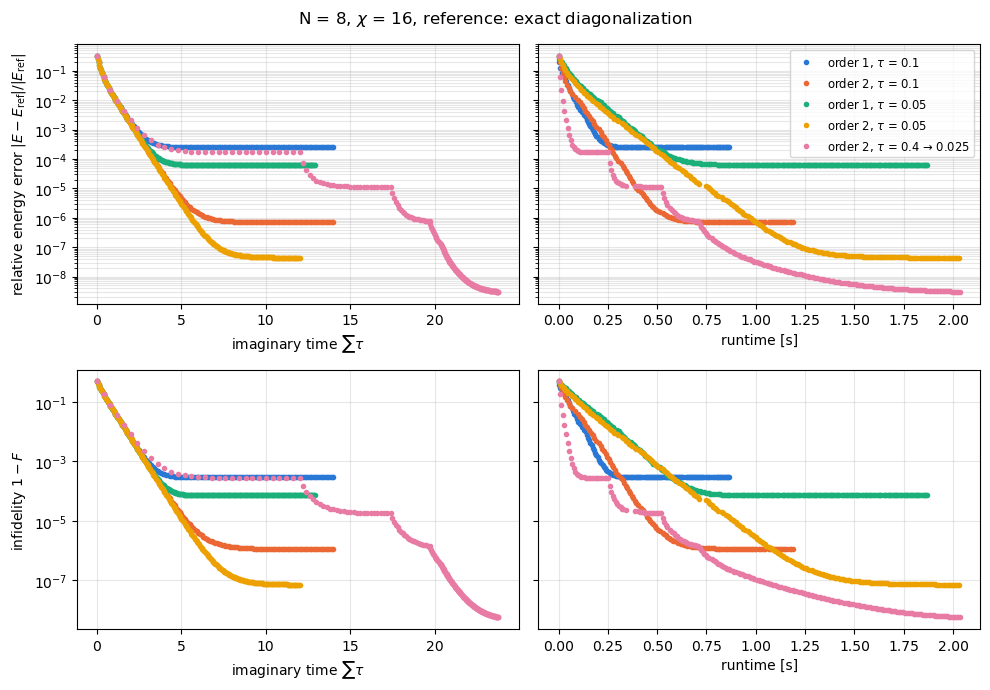

In [17]:
plot_convergence(small_runs, E0, psi0, f"N = {N}, $\\chi$ = {D}, reference: exact diagonalization")

## Large system
For $N = 40$, exact diagonalization is impossible. As a reference, we use the second order evolution with the time step decreasing from $\tau = 0.4$ to $\tau = 0.0125$, with the stricter criterion $10^{-9}$ for decreasing the time step, and take the final state and energy. Then we compare the runs with $\tau = 0.1$ of first and second order, and the run with the time step decreasing to $\tau = 0.025$, to this reference. Now both the Trotter error and the truncation to $\chi = D = 16$ contribute.

In [18]:
N = 40
reference = evolve(product_state(N), J, beta, [0.4, 0.2, 0.1, 0.05, 0.025, 0.0125], 2, "reference",
                   switchtol=1e-9, **settings)
E_ref, psi_ref = reference["energies"][-1], reference["states"][-1]
print("reference: %d steps, runtime %.1f s, E_ref = %.12f, energy per site = %.12f"
      % (len(reference["energies"]) - 1, reference["runtime"][-1], E_ref, E_ref / N))

reference: 276 steps, runtime 20.6 s, E_ref = -44.336934982037, energy per site = -1.108423374551


order 1, $\tau$ = 0.1           221 steps, runtime  10.7 s, relative energy error = 1.65e-04, infidelity = 8.73e-04
order 2, $\tau$ = 0.1           200 steps, runtime  14.7 s, relative energy error = 5.70e-07, infidelity = 3.46e-06
order 2, $\tau$ = 0.4 $\to$ 0.025  229 steps, runtime  15.9 s, relative energy error = 1.92e-09, infidelity = 6.49e-09


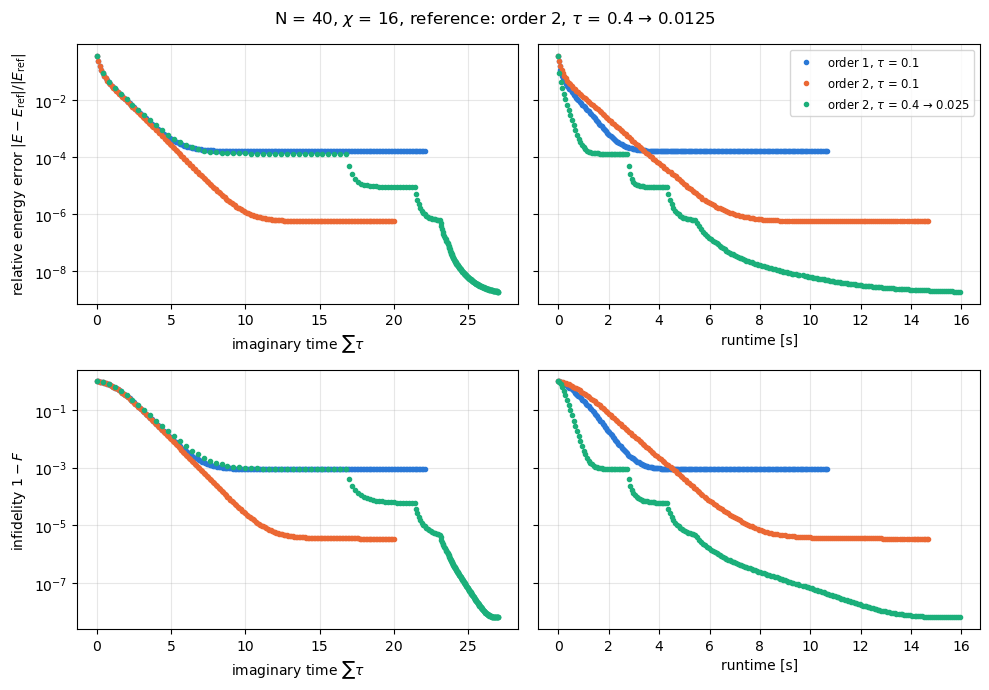

In [19]:
large_runs = [evolve(product_state(N), J, beta, [0.1], order, f"order {order}, $\\tau$ = 0.1", **settings) for order in [1, 2]]
large_runs.append(evolve(product_state(N), J, beta, [0.4, 0.2, 0.1, 0.05, 0.025], 2,
                         "order 2, $\\tau$ = 0.4 $\\to$ 0.025", switchtol=1e-8, **settings))

for run in large_runs:
    print("%-30s %4d steps, runtime %5.1f s, relative energy error = %.2e, infidelity = %.2e"
          % (run["label"], len(run["energies"]) - 1, run["runtime"][-1], abs(run["energies"][-1] - E_ref) / abs(E_ref),
             1 - abs(exp_val(run["states"][-1], bra=psi_ref))))

plot_convergence(large_runs, E_ref, psi_ref, f"N = {N}, $\\chi$ = {D}, reference: order 2, $\\tau$ = 0.4 $\\to$ 0.0125")

### Bond dimension
The initial product state has bond dimension 1. A gate on the sites $k, k+1$ has an MPO bond dimension of at most 4, so it can increase the bond dimension of the MPS bond `b{k+1}` by at most a factor of 4. The truncated SVD in `apply_mpo` drops singular values below $10^{-14}$ and keeps at most $\chi$ of them. Near the boundaries, the bond dimension is also limited by the dimension of the smaller part of the chain, $\min(2^k, 2^{N-k})$ for the bond `b{k}`.

`plot_bond_dimensions` shows the maximal bond dimension and the bond dimension in the middle of the chain at every time step (left), and the bond dimension of every bond after the first few time steps (right), for the second order run.

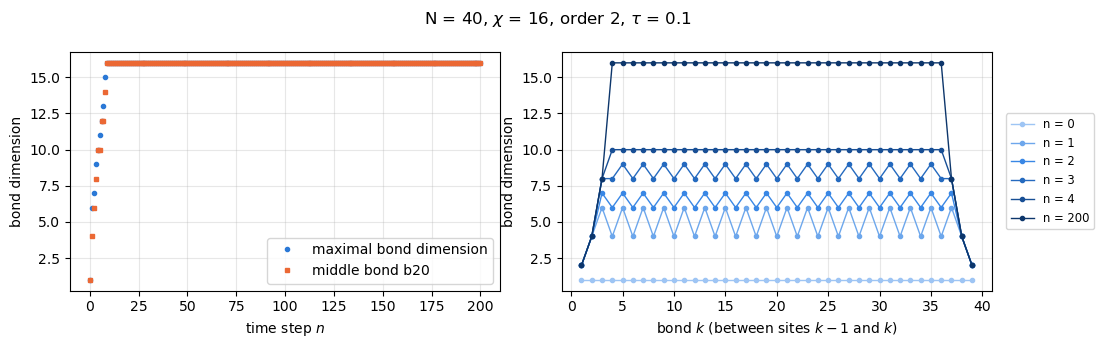

In [20]:
def bond_dimensions(psi):
    # dimensions of the bonds b1, ..., b{N-1} between the sites
    return [psi[k].bond(f"b{k+1}").dim() for k in range(len(psi) - 1)]

def plot_bond_dimensions(run, title):
    dims = [bond_dimensions(psi) for psi in run["states"]]
    steps = list(range(len(dims)))
    middle = len(dims[0]) // 2
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))
    ax1.plot(steps, [max(d) for d in dims], "o", color="#2a78d6", markersize=3, label="maximal bond dimension")
    ax1.plot(steps, [d[middle] for d in dims], "s", color="#eb6834", markersize=3, label=f"middle bond b{middle + 1}")
    ax1.set_xlabel(r"time step $n$")
    ax1.set_ylabel("bond dimension")
    ax1.legend(loc="lower right")
    shades = ["#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]  # light to dark: early to late
    shown = [0, 1, 2, 3, 4, len(dims) - 1]
    for shade, n in zip(shades, shown):
        ax2.plot(range(1, len(dims[n]) + 1), dims[n], "o-", color=shade, markersize=3, linewidth=1, label=f"n = {n}")
    ax2.set_xlabel(r"bond $k$ (between sites $k-1$ and $k$)")
    ax2.set_ylabel("bond dimension")
    ax2.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize="small")
    for ax in (ax1, ax2):
        ax.grid(True, alpha=0.3)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_bond_dimensions(large_runs[1], f"N = {N}, $\\chi$ = {D}, {large_runs[1]['label']}")

## Quench dynamics
Now we use the same code for a real time evolution. We prepare the ground state $|\psi_0\rangle$ of $H(\beta_0)$ with $\beta_0 = -0.7$, in the ordered phase $|\beta| < J$, and evolve it with the Hamiltonian $H(\beta_q)$ with $\beta_q = -1.2$, in the disordered phase $|\beta| > J$:
$$
|\psi(t)\rangle = e^{-iH(\beta_q)t} |\psi_0\rangle .
$$
This sudden change of the parameter is a quench across the critical point $|\beta| = J$. The Loschmidt echo is the probability to find the system in its initial state,
$$
\mathcal{L}(t) = |\langle\psi_0|\psi(t)\rangle|^2 = e^{-N\lambda(t)} .
$$
It decreases exponentially with the system size, so we show the rate function $\lambda(t) = -\ln\mathcal{L}(t)/N$. For quenches across the critical point, $\lambda(t)$ develops kinks at critical times in the thermodynamic limit, the so-called dynamical quantum phase transitions.

For real $t$, `time_evolve` does not normalize the state. The time evolution is unitary, but the truncation to $\chi$ reduces the norm slightly, so we divide by $\langle\psi(t)|\psi(t)\rangle$. The energy $\langle H(\beta_q)\rangle$ is conserved by the exact evolution; its change measures the Trotter and truncation errors.

For the small system, the exact Loschmidt amplitude follows from the eigenstates $|n\rangle$ and energies $E_n$ of $H(\beta_q)$:
$$
\langle\psi_0|\psi(t)\rangle = \sum_n |\langle n|\psi_0\rangle|^2 e^{-iE_n t} .
$$

In [21]:
def loschmidt_rate(states, psi0):
    N = len(psi0)
    return [-math.log(abs(exp_val(psi, bra=psi0)) ** 2 / exp_val(psi).real) / N for psi in states]

def exact_loschmidt_rate(N, J, beta0, beta_q, times):
    _, V0 = cytnx.linalg.Eigh(dense_hamiltonian(N, J, beta0))
    Eq, Vq = cytnx.linalg.Eigh(dense_hamiltonian(N, J, beta_q))
    c = cytnx.linalg.Matmul(Vq.permute(1, 0).contiguous(), V0[:, 0:1].contiguous())  # c_n = <n|psi0>
    weights = [abs(c[n, 0].item()) ** 2 for n in range(2 ** N)]
    energies = [Eq[n].item() for n in range(2 ** N)]
    rates = []
    for t in times:
        amplitude = sum(w * cmath.exp(-1j * E * t) for w, E in zip(weights, energies))
        rates.append(-math.log(abs(amplitude) ** 2) / N)
    return rates

We evolve with the second order Trotter decomposition and the time step $dt = 0.05$ up to $t = 5$. For $N = 8$, the initial state is the exact ground state and $\chi = 16$ is exact. For $N = 40$, the initial state is the reference ground state from above, and we compare the bond dimensions $\chi = 16$ and $\chi = 32$: the entanglement grows during the real time evolution, and the truncation error increases with time.

In [22]:
beta_q = -1.2
dt = 0.05
nsteps = 100
times = [n * dt for n in range(nsteps + 1)]

N = 8
_, psi0_small = exact_ground_state(N, J, beta)
exact_rate = exact_loschmidt_rate(N, J, beta, beta_q, times)

quench_runs = []
for N, psi0, chi in [(8, psi0_small, 16), (40, psi_ref, 16), (40, psi_ref, 32)]:
    energies, psi, norms, states, runtimes = time_evolve(psi0, J, beta_q, dt, chi=chi, order=2, nsteps=nsteps,
                                                         maxit=20, tol=1e-10, save_states=True)
    quench_runs.append(dict(label=f"N = {N}, $\\chi$ = {chi}", rate=loschmidt_rate(states, psi0), energies=energies))
    print("N = %2d, chi = %2d: runtime %5.1f s, maximal bond dimension %2d, maximal relative energy change %.2e"
          % (N, chi, runtimes[-1], max(bond_dimensions(psi)),
             max(abs(E - energies[0]) / abs(energies[0]) for E in energies)))

print("N = 8: maximal deviation of the rate function from the exact result: %.2e"
      % max(abs(a - b) for a, b in zip(quench_runs[0]["rate"], exact_rate)))

N =  8, chi = 16: runtime   1.4 s, maximal bond dimension 16, maximal relative energy change 1.21e-04


N = 40, chi = 16: runtime  10.0 s, maximal bond dimension 16, maximal relative energy change 4.47e-03


N = 40, chi = 32: runtime  28.9 s, maximal bond dimension 32, maximal relative energy change 2.31e-03
N = 8: maximal deviation of the rate function from the exact result: 3.45e-04


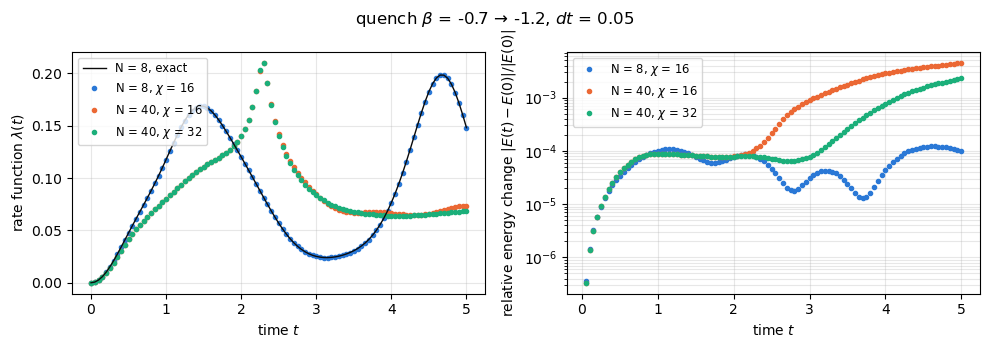

In [23]:
colors = ["#2a78d6", "#eb6834", "#1baf7a"]  # one color per run
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
ax1.plot(times, exact_rate, "-", color="#0b0b0b", linewidth=1, zorder=3, label="N = 8, exact")
for color, run in zip(colors, quench_runs):
    ax1.plot(times, run["rate"], "o", color=color, markersize=3, label=run["label"])
    energy_change = [abs(E - run["energies"][0]) / abs(run["energies"][0]) for E in run["energies"][1:]]
    ax2.semilogy(times[1:], energy_change, "o", color=color, markersize=3, label=run["label"])
ax1.set_ylabel(r"rate function $\lambda(t)$")
ax2.set_ylabel(r"relative energy change $|E(t) - E(0)| / |E(0)|$")
for ax in (ax1, ax2):
    ax.set_xlabel("time $t$")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize="small")
fig.suptitle(f"quench $\\beta$ = {beta} $\\to$ {beta_q}, $dt$ = {dt}")
plt.tight_layout()
plt.show()

For $N = 8$, the MPS result agrees with the exact rate function up to the Trotter error. For $N = 40$, the rate function has a sharp peak, which develops into the kink of a dynamical quantum phase transition for $N \to \infty$; for $N = 8$, the finite size smooths it into a broad maximum.

The relative energy change first grows to about $10^{-4}$ for all runs: this is the Trotter error, which does not depend on $N$ or $\chi$. For $N = 40$, the entanglement grows with time until the truncation to $\chi$ dominates the error. The results for $\chi = 16$ and $\chi = 32$ separate at later times, and the energy change grows faster for $\chi = 16$.